# Phân loại chữ số viết tay bằng kiến trúc FCNN


## 1. Thư viện

---



In [24]:
import numpy as np
import matplotlib.pyplot as plt

%tensorflow_version 2.x
import tensorflow as tf
from tensorflow import keras

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


## 2. Tiền xử lý dữ liệu

---



In [2]:
#Tải dataset
mnist = tf.keras.datasets.mnist
train_data, test_data = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#Chia dữ liệu thành các đặc trưng và nhãn
train_images, train_labels = train_data
test_images, test_labels = test_data

In [4]:
#Chuẩn hóa giá trị pixel
X_train = train_images.reshape((60000, 784))
X_train = X_train.astype('float32') / 255
X_test = test_images.reshape((10000, 784))
X_test = X_test.astype('float32') / 255
y_train = tf.keras.utils.to_categorical(train_labels)
y_test = tf.keras.utils.to_categorical(test_labels)

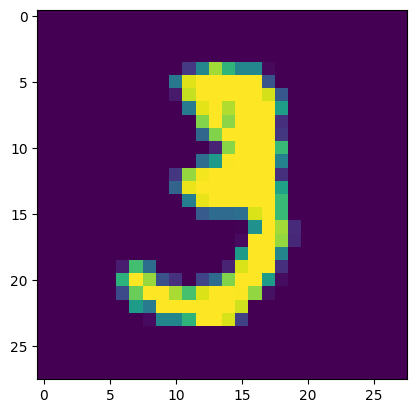

In [5]:
#Mẫu dữ liệu MNIST
plt.imshow(train_images[10])
plt.show()

## 3. Neural Network

---



### 3.1. Định nghĩa mô hình

In [6]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=(784,)))

model.add(tf.keras.layers.Dense(512, activation='relu'))
model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(64, activation='relu'))

model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,050 (2.19 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Chọn tham số cho mô hình
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### 3.2. Huấn luyện mô hình

In [9]:
#tham số huấn luyện
num_epochs = 30
batch_size = 6000

#Huấn luyện mô hình
history = model.fit(X_train,
                      y_train,
                      epochs=num_epochs,
                      batch_size=batch_size,
                      validation_data=(X_test, y_test))

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.5581 - loss: 1.5173 - val_accuracy: 0.8195 - val_loss: 0.6300
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8620 - loss: 0.4693 - val_accuracy: 0.9043 - val_loss: 0.3405
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9136 - loss: 0.2970 - val_accuracy: 0.9293 - val_loss: 0.2449
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9345 - loss: 0.2279 - val_accuracy: 0.9395 - val_loss: 0.2038
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9449 - loss: 0.1889 - val_accuracy: 0.9462 - val_loss: 0.1825
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9532 - loss: 0.1622 - val_accuracy: 0.9552 - val_loss: 0.1505
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9584 - loss: 0.1411 - val_accuracy: 0.9575 - val_loss: 0.1401
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9637 - loss: 0.1247 - val_accuracy: 0.9633 - 

In [10]:
model.save('my_model.keras')

### 3.3. Các chỉ số

In [11]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print('Test Accuracy:', test_accuracy)
print('Test Loss:', test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9812 - loss: 0.0700
Test Accuracy: 0.9811999797821045
Test Loss: 0.07002215832471848


In [12]:
#Lưu chỉ số
metrics = history.history

In [13]:
#Lưu giá trị hàm mất mát
training_loss_list = metrics['loss']
test_loss_list = metrics['val_loss']

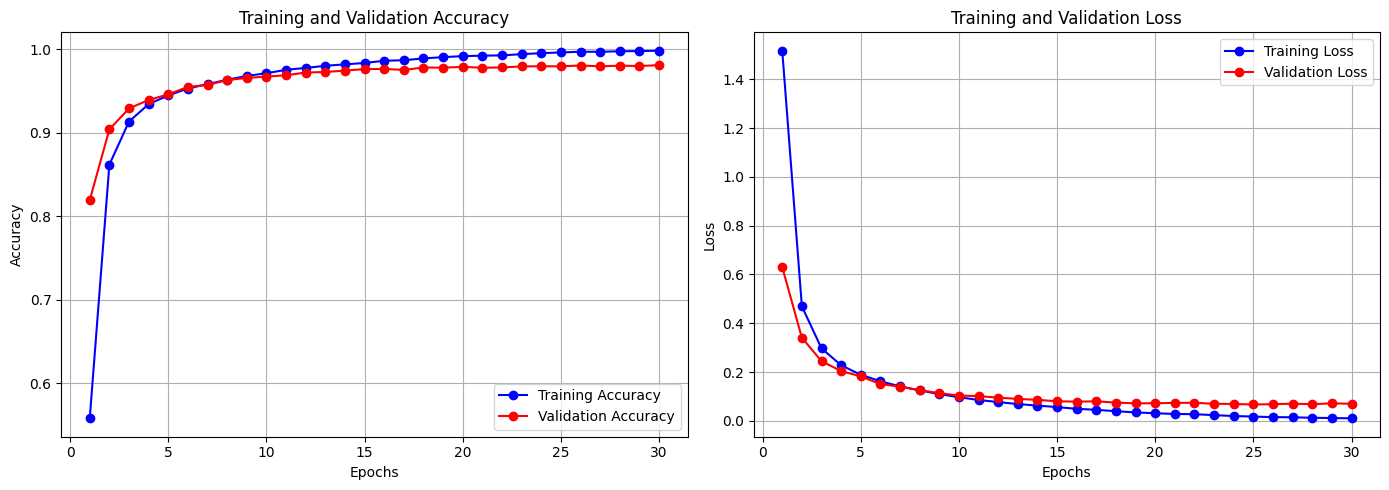

In [14]:
#Vẽ đồ thị accuracy và loss theo epochs
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    #Đồ thị Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    #Đồ thị Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

#Gọi hàm để hiển thị
plot_training_history(history)

In [15]:
train_accuracy_list = metrics['accuracy']
test_accuracy_list = metrics['val_accuracy']

## 4. Dự đoán

---



In [16]:
#Tạo dự đoán cho mô hình đã huấn luyện
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


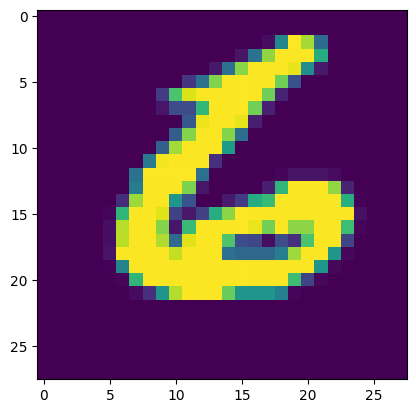

In [17]:
#Chọn mẫu
index = 9999

#Hiển thị ảnh mẫu
plt.imshow(test_images[index])
plt.show()

In [18]:
print("Prediction:", np.argmax(predictions[index]))

Prediction: 6


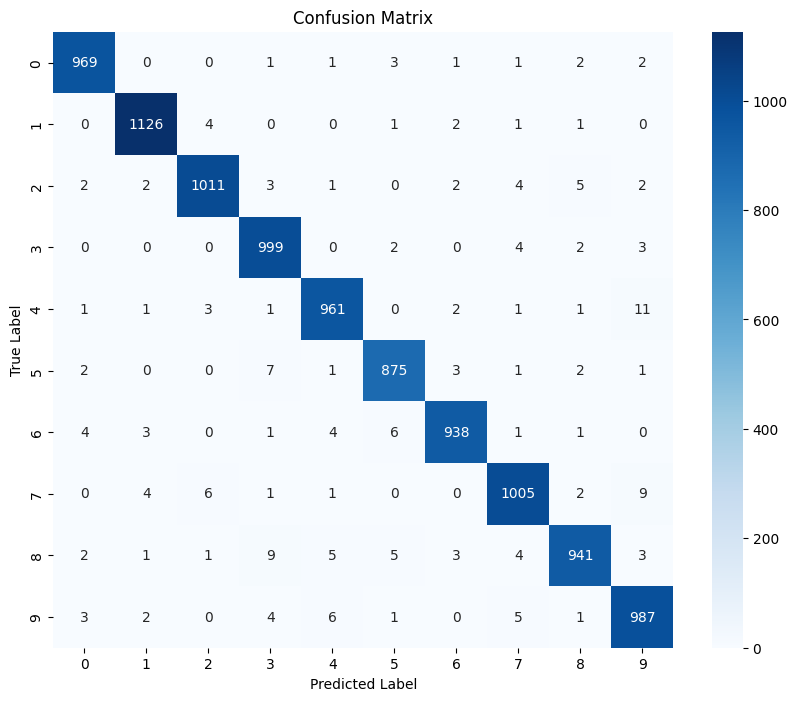

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Ma trận nhầm lẫn (Confusion Matrix)
y_pred_classes = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred_classes)

#Vẽ ma trận
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## 5. Config chuyển đổi sang HLS

---

In [20]:
!pip install hls4ml[profiling] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.7 MB/s eta 0:00:00


In [23]:
import hls4ml
import os

#Tạo config từ mô hình Keras
config = hls4ml.utils.config_from_keras_model(model, granularity='name')

#Cấu hình chung cho model
config['Model']['Precision'] = 'ap_fixed<16,6>'
config['Model']['Strategy'] = 'Resource'


#Tối ưu từng layer
for layer in config['LayerName']:
    config['LayerName'][layer]['Precision'] = {
        'weight': 'ap_fixed<16,6>',
        'bias': 'ap_fixed<16,6>',
        'result': 'ap_fixed<16,6>',
        'accum': 'ap_fixed<24,10>'
    }
    if 'dense' in layer.lower():
        config['LayerName'][layer]['ReuseFactor'] = 64

#Chuyển sang Vitis HLS
output_dir = 'hls_mlp_vu19p'
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    output_dir=output_dir,
    part='xcvu19p-fsva3824-2-e',
    backend='Vitis'
)
hls_model.write()

#Xóa pragma pipeline/unroll
cpp_file = os.path.join(output_dir, 'firmware/myproject.cpp')
with open(cpp_file, 'r') as f:
    lines = f.readlines()
with open(cpp_file, 'w') as f:
    for line in lines:
        if '#pragma HLS PIPELINE' not in line and '#pragma HLS UNROLL' not in line:
            f.write(line)

#Nén file
!zip -r hls_fcnn.zip {output_dir}

#Tải file
from google.colab import files
files.download('hls_fcnn.zip')

  adding: hls_mlp_vu19p/ (stored 0%)
  adding: hls_mlp_vu19p/project.tcl (deflated 49%)
  adding: hls_mlp_vu19p/myproject_bridge.cpp (deflated 67%)
  adding: hls_mlp_vu19p/hls4ml_config.yml (deflated 82%)
  adding: hls_mlp_vu19p/myproject_test.cpp (deflated 71%)
  adding: hls_mlp_vu19p/firmware/ (stored 0%)
  adding: hls_mlp_vu19p/firmware/parameters.h (deflated 86%)
  adding: hls_mlp_vu19p/firmware/ap_types/ (stored 0%)
  adding: hls_mlp_vu19p/firmware/ap_types/ap_fixed_special.h (deflated 70%)
  adding: hls_mlp_vu19p/firmware/ap_types/ap_float.h (deflated 75%)
  adding: hls_mlp_vu19p/firmware/ap_types/ap_shift_reg.h (deflated 58%)
  adding: hls_mlp_vu19p/firmware/ap_types/hls_math.h (deflated 66%)
  adding: hls_mlp_vu19p/firmware/ap_types/ap_common.h (deflated 70%)
  adding: hls_mlp_vu19p/firmware/ap_types/ap_fixed.h (deflated 84%)
  adding: hls_mlp_vu19p/firmware/ap_types/ap_fixed_ref.h (deflated 87%)
  adding: hls_mlp_vu19p/firmware/ap_types/hls_stream.h (deflated 63%)
  adding: hl

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>